In [ ]:
%%capture
!pip install pycaret

In [49]:
from pycaret.datasets import get_data
from pycaret.classification import *
import pandas as pd

In [50]:
# Diabetes
data = get_data('diabetes', profile=False)

# Dropar os valores com zeros
columns = ['Triceps skin fold thickness (mm)', 'Body mass index (weight in kg/(height in m)^2)', 'Diastolic blood pressure (mm Hg)']

data = data[(data[columns] != 0).all(axis=1)]
data

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
6,3,78,50,32,88,31.0,0.248,26,1
...,...,...,...,...,...,...,...,...,...
761,9,170,74,31,0,44.0,0.403,43,1
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0


In [51]:
# Setup
s = setup(data, target='Class variable', session_id=123)

,Description,Value
0,Session id,123
1,Target,Class variable
2,Target type,Binary
3,Original data shape,"(537, 9)"
4,Transformed data shape,"(537, 9)"
5,Transformed train set shape,"(375, 9)"
6,Transformed test set shape,"(162, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


In [52]:
best = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8056,0.8611,0.6391,0.7697,0.6790,0.5439,0.5627,0.2800
ridge,Ridge Classifier,0.7922,0.8732,0.5981,0.7563,0.6481,0.5063,0.5255,0.0300
lda,Linear Discriminant Analysis,0.7922,0.8738,0.5981,0.7563,0.6481,0.5063,0.5255,0.0330
ada,Ada Boost Classifier,0.7897,0.8422,0.6321,0.7168,0.6565,0.5086,0.5208,0.2880
lr,Logistic Regression,0.7895,0.8717,0.6064,0.7295,0.6512,0.5040,0.5162,1.4790
lightgbm,Light Gradient Boosting Machine,0.7869,0.8726,0.6397,0.7088,0.6586,0.5065,0.5196,0.1390
rf,Random Forest Classifier,0.7762,0.8551,0.5679,0.7146,0.6136,0.4636,0.4816,0.2560
xgboost,Extreme Gradient Boosting,0.7656,0.8594,0.6154,0.6767,0.6293,0.4609,0.4736,0.0770
dt,Decision Tree Classifier,0.7632,0.7347,0.6494,0.6550,0.6484,0.4707,0.4733,0.0290
nb,Naive Bayes,0.7628,0.8504,0.6385,0.6502,0.6342,0.4604,0.4693,0.0720


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [53]:
# Printar melhor modele
print(best)

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=123, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)


In [54]:
# Criar modelo
gbc = create_model('gbc')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8421,0.8246,0.6923,0.8182,0.7500,0.6358,0.6405
1,0.8158,0.8338,0.6154,0.8000,0.6957,0.5668,0.5768
2,0.7632,0.9138,0.8462,0.6111,0.7097,0.5183,0.5379
3,0.6579,0.7538,0.5385,0.5000,0.5185,0.2538,0.2542
4,0.8421,0.8646,0.6154,0.8889,0.7273,0.6213,0.6421
5,0.8919,0.9233,0.9167,0.7857,0.8462,0.7636,0.7690
6,0.8108,0.8433,0.5000,0.8571,0.6316,0.5159,0.5498
7,0.8649,0.9333,0.8333,0.7692,0.8000,0.6982,0.6995
8,0.7838,0.8500,0.4167,0.8333,0.5556,0.4330,0.4784


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [55]:
# Avaliar o modelo
evaluate_model(gbc)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

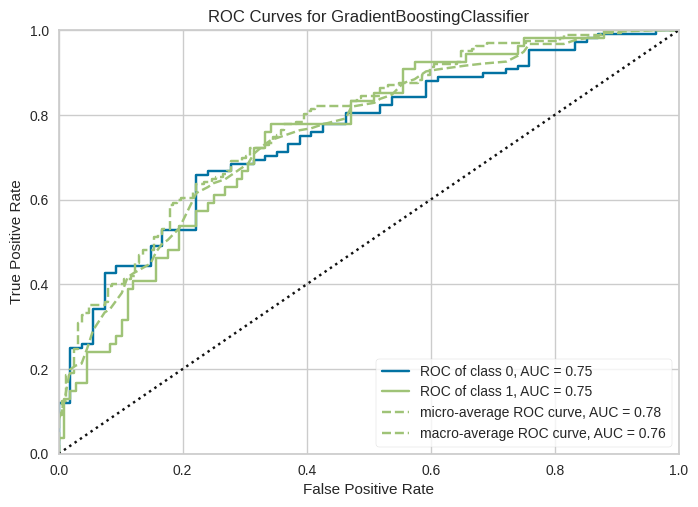

In [56]:
# Plotagem separada
plot_model(gbc, plot='auc')

In [57]:
# Previsões com dados presentes no dataset
predictions = predict_model(gbc, data=data, raw_score=True)
predictions.head(10)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.9013,0.9343,0.8603,0.8462,0.8532,0.7789,0.7789


,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable,prediction_label,prediction_score_0,prediction_score_1
0,6,148,72,35,0,33.599998,0.627,50,1,1,0.0447,0.9553
1,1,85,66,29,0,26.600000,0.351,31,0,0,0.9689,0.0311
3,1,89,66,23,94,28.100000,0.167,21,0,0,0.9938,0.0062
4,0,137,40,35,168,43.099998,2.288,33,1,1,0.0537,0.9463
6,3,78,50,32,88,31.000000,0.248,26,1,0,0.9910,0.0090
8,2,197,70,45,543,30.500000,0.158,53,1,1,0.1843,0.8157
13,1,189,60,23,846,30.100000,0.398,59,1,1,0.0066,0.9934
14,5,166,72,19,175,25.799999,0.587,51,1,1,0.0512,0.9488
16,0,118,84,47,230,45.799999,0.551,31,1,1,0.1342,0.8658
18,1,103,30,38,83,43.299999,0.183,33,0,0,0.7863,0.2137


In [60]:
# Previsões com dados que não estão presentes no dataset
df = pd.DataFrame(columns=data.columns.difference(['Class variable'], sort=False))

# Adicionar as informações no df
imc = (60/(1.74**2)) # Peso / Altura²
df.loc[0] = [0, 148, 72, 35, 80, imc, 1.627, 22]

In [61]:
# Salvando o modelo
save_model(gbc, 'modelo_diabetes_gbc')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Number of times pregnant',
                                              'Plasma glucose concentration a 2 '
                                              'hours in an oral glucose '
                                              'tolerance test',
                                              'Diastolic blood pressure (mm Hg)',
                                              'Triceps skin fold thickness (mm)',
                                              '2-Hour serum insulin (mu U/ml)',
                                              'Body mass index (weight in '
                                              'kg/(height in m)^2)',
                                              'Diabetes pedigre...
                                             criterion='friedman_mse', init=None,
                                      

In [62]:
# Carregando o modelo
loaded_model = load_model("modelo_diabetes_gbc")
print(loaded_model)

Transformation Pipeline and Model Successfully Loaded
Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Number of times pregnant',
                                             'Plasma glucose concentration a 2 '
                                             'hours in an oral glucose '
                                             'tolerance test',
                                             'Diastolic blood pressure (mm Hg)',
                                             'Triceps skin fold thickness (mm)',
                                             '2-Hour serum insulin (mu U/ml)',
                                             'Body mass index (weight in '
                                             'kg/(height in m)^2)',
                                             'Diab...
                                            criterion='friedman_mse', init=None,

In [59]:
# Fazer predições
predictions = predict_model(gbc, data=df, raw_score=True)
predictions

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),prediction_label,prediction_score_0,prediction_score_1
0,0.0,148.0,72.0,35.0,80.0,19.817677,1.627,22.0,0,0.9305,0.0695
